[Load] Qwen rows:   36
[Load] Mask rows:   36
[Load] Unmask rows: 36


Saved: /home/dslabra5/sae4dlm/steering/eval_steer/sae_metrics_qwen_dream_mask_unmask_3x3.png
Saved: /home/dslabra5/sae4dlm/steering/eval_steer/sae_metrics_qwen_dream_mask_unmask_3x3.pdf


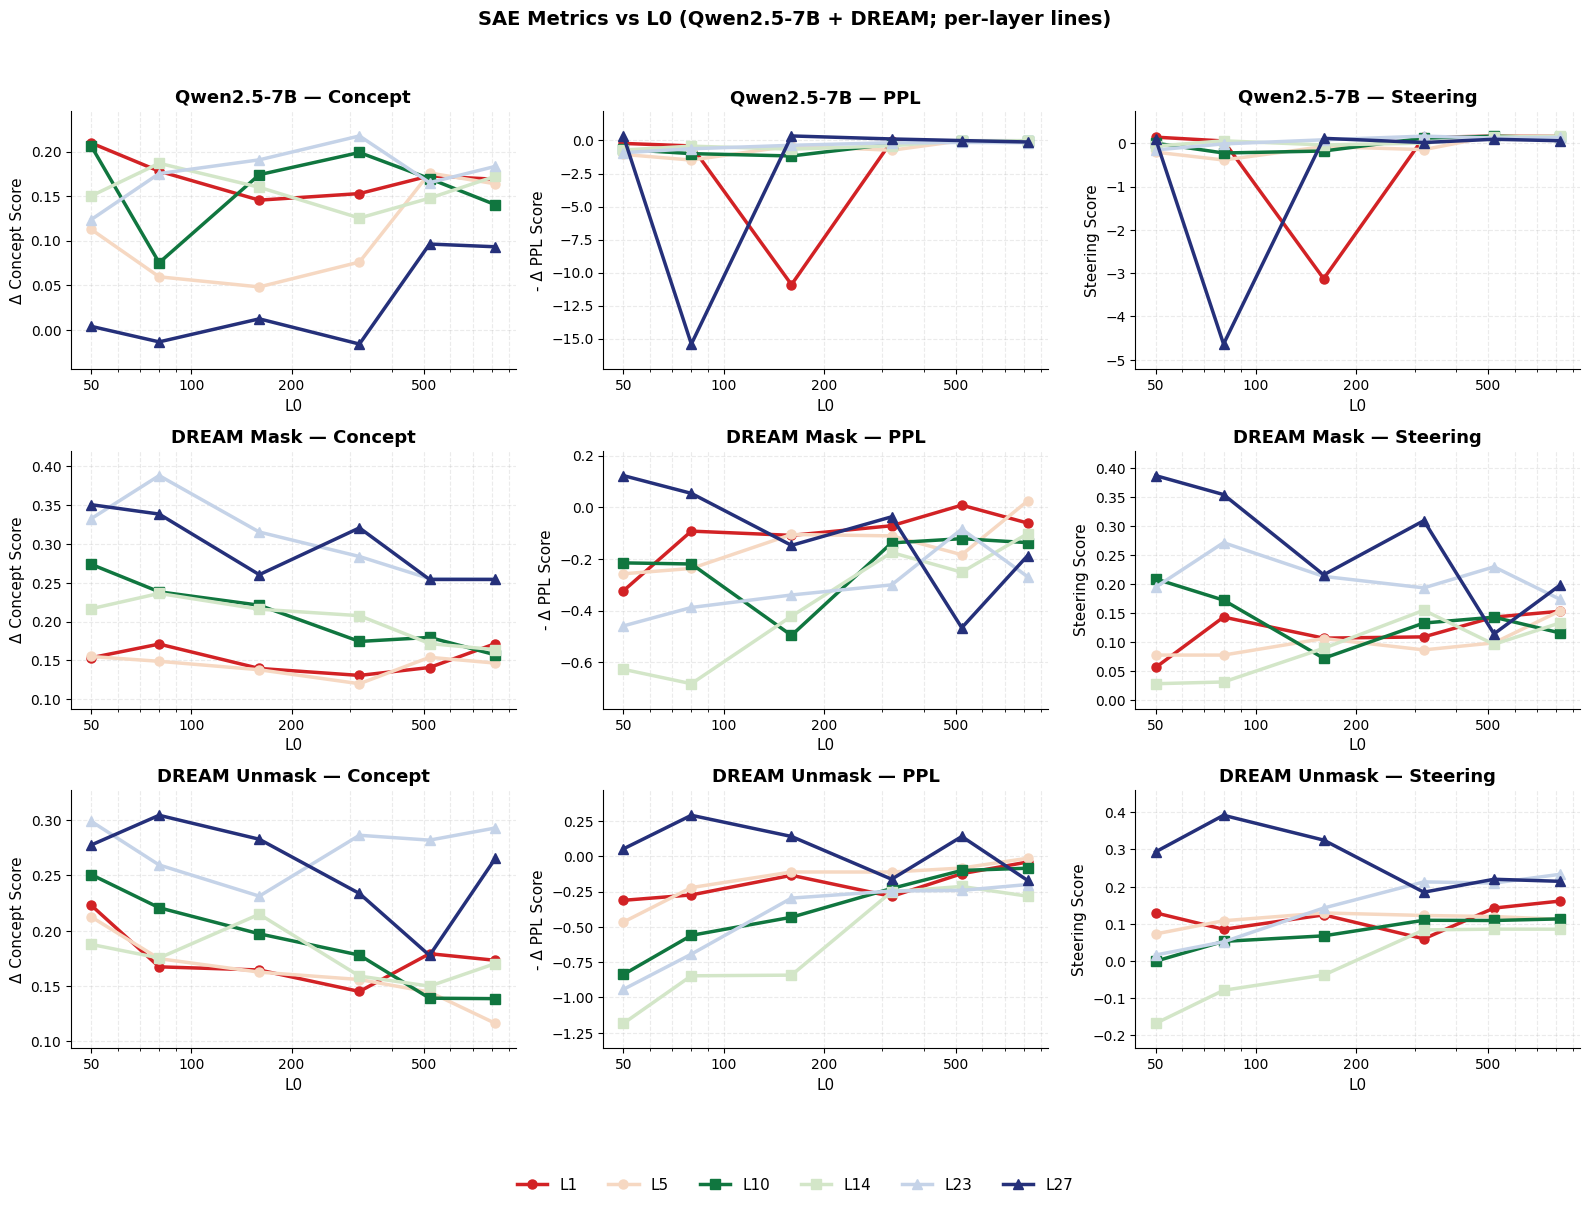

In [2]:
# -*- coding: utf-8 -*-
"""
Plot SAE steering evaluation metrics vs L0 for:
  Row 1: Qwen2.5-7B SAEs
  Row 2: DREAM Mask-token SAEs
  Row 3: DREAM Unmask-token SAEs

We plot 3 rows × 3 columns:
  Col 1: Concept Δ (normalized)
  Col 2: PPL gain (normalized; positive is better)
  Col 3: Steering score = concept_norm + λ * ppl_norm

Each subplot shows multiple layers (1, 5, 10, 14, 23, 27) as separate lines,
using the SAME color + marker scheme as the reference figure:
  - L1, L5   (shallow): circle markers, red / light-peach
  - L10, L14 (middle):  square markers, dark / light green
  - L23, L27 (deep):    triangle markers, light / dark blue

Inputs (JSON directories):
  - /home/dslabra5/sae4dlm/steering/eval_steering_file/qwen_sae_steering_scores
      e.g. steer_qwen2.5_layer1_l0_50.json
  - /home/dslabra5/sae4dlm/steering/eval_steering_file/dream_mask_sae_steering_scores
      e.g. steer_dlm_layer1_l0_50.json
  - /home/dslabra5/sae4dlm/steering/eval_steering_file/dream_unmask_sae_steering_scores
      e.g. steer_dlm_layer1_l0_50.json

Each JSON file is one SAE (one layer, one L0), containing many features.
For each feature we use ONLY:
  - avg_concept_score_without_steer
  - avg_concept_score_after_steer
  - avg_ppl_without_steer
  - avg_ppl_after_steer

Definitions:
  ΔC_raw  = concept_after - concept_before
  ΔP_raw  = ppl_after - ppl_before  (as requested)

But "lower ppl is better", so we define a positive-is-better fluency gain:
  PPL_gain = -(ΔP_raw) = ppl_before - ppl_after

Normalization:
  concept_norm = ΔC_raw / concept_scale  (scale = 1 if scores in [0,1] else 100)
  ppl_norm     = PPL_gain / ppl_before   (relative improvement)

Feature steering score:
  steering = concept_norm + λ * ppl_norm

SAE-level metric:
  mean over all features in that SAE file
  (missing/invalid features contribute 0 and still count in the denominator)

λ (lambda_quality):
  Higher λ => steering score is more influenced by fluency improvements (ppl decrease).
"""

import json
import math
import re
from pathlib import Path
from typing import Any, Dict, Optional, Tuple, List

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D


# ---------------- User parameters ----------------
QWEN_DIR = Path("/home/dslabra5/sae4dlm/steering/eval_steering_file/qwen_sae_steering_scores")
MASK_DIR = Path("/home/dslabra5/sae4dlm/steering/eval_steering_file/dream_mask_sae_steering_scores")
UNMASK_DIR = Path("/home/dslabra5/sae4dlm/steering/eval_steering_file/dream_unmask_sae_steering_scores")

OUT_PNG = Path("sae_metrics_qwen_dream_mask_unmask_3x3.png")
OUT_PDF = Path("sae_metrics_qwen_dream_mask_unmask_3x3.pdf")

# λ controls the tradeoff in the combined steering score:
# steering = concept_norm + λ * ppl_norm
LAMBDA_QUALITY = 0.3

# Layers we care about (and have colors/markers for)
TARGET_LAYERS = [1, 5, 10, 14, 23, 27]

# Filename patterns (support DREAM + Qwen)
FILENAME_RES = [
    re.compile(r"steer_dlm_layer(?P<layer>\d+)_l0_(?P<l0>\d+)\.json$"),
    re.compile(r"steer_qwen2\.5_layer(?P<layer>\d+)_l0_(?P<l0>\d+)\.json$"),
]


# ---------------- Colors & markers (match reference figure) ----------------
def rgb(r: int, g: int, b: int) -> Tuple[float, float, float]:
    """Convert 0-255 RGB to 0-1 matplotlib color tuple."""
    return (r / 255.0, g / 255.0, b / 255.0)


LAYER_COLORS = {
    1: rgb(210, 34, 37),      # red
    5: rgb(246, 216, 194),    # light peach
    10: rgb(16, 118, 63),     # dark green
    14: rgb(211, 230, 200),   # light green
    23: rgb(197, 211, 232),   # light blue
    27: rgb(37, 48, 122),     # dark blue
}

GROUP_MARKERS = {
    "Shallow": "o",  # circle
    "Middle": "s",   # square
    "Deep": "^",     # triangle
}

GROUP_LAYERS = {
    "Shallow": [1, 5],
    "Middle": [10, 14],
    "Deep": [23, 27],
}


def choose_marker_for_layer(layer: int) -> str:
    """Return marker style (o/s/^ ) based on group of the layer."""
    for grp, layers in GROUP_LAYERS.items():
        if layer in layers:
            return GROUP_MARKERS[grp]
    return "o"


# ---------------- Core helpers ----------------
def _safe_float(x: Any) -> Optional[float]:
    try:
        if x is None:
            return None
        v = float(x)
        if math.isnan(v) or math.isinf(v):
            return None
        return v
    except Exception:
        return None


def parse_layer_l0(path: Path) -> Optional[Tuple[int, int]]:
    """Parse (layer, l0) from supported filename patterns."""
    for rx in FILENAME_RES:
        m = rx.search(path.name)
        if m:
            return int(m.group("layer")), int(m.group("l0"))
    return None


def detect_concept_scale(c_before: float, c_after: float) -> float:
    """
    Concept scores might be either in [0,1] or [0,100].
    Normalize to a dimensionless delta by dividing by this scale.
    """
    m = max(abs(c_before), abs(c_after))
    return 1.0 if m <= 1.0 + 1e-9 else 100.0


def feature_metrics_from_feature_dict(
    feature_dict: Dict[str, Any],
    lambda_quality: float
) -> Tuple[float, float, float, bool]:
    """
    Returns (concept_norm, ppl_norm, steering, ok).

    Uses only:
      avg_concept_score_without_steer
      avg_concept_score_after_steer
      avg_ppl_without_steer
      avg_ppl_after_steer

    Definitions (as requested):
      ΔC_raw = after - before
      ΔP_raw = after - before

    But lower ppl is better, so fluency gain term is:
      PPL_gain = -(ΔP_raw) = before - after

    Normalization:
      concept_norm = ΔC_raw / concept_scale
      ppl_norm     = PPL_gain / ppl_before
    """
    c_b = _safe_float(feature_dict.get("avg_concept_score_without_steer"))
    c_a = _safe_float(feature_dict.get("avg_concept_score_after_steer"))
    p_b = _safe_float(feature_dict.get("avg_ppl_without_steer"))
    p_a = _safe_float(feature_dict.get("avg_ppl_after_steer"))

    if c_b is None or c_a is None or p_b is None or p_a is None or p_b <= 0:
        return 0.0, 0.0, 0.0, False

    # Concept: after - before
    delta_c_raw = c_a - c_b
    c_scale = detect_concept_scale(c_b, c_a)
    concept_norm = delta_c_raw / c_scale

    # PPL: after - before, then convert to positive-is-better gain
    delta_p_raw = p_a - p_b
    ppl_gain = -delta_p_raw  # == (p_b - p_a)
    ppl_norm = ppl_gain / p_b

    steering = concept_norm + lambda_quality * ppl_norm
    return float(concept_norm), float(ppl_norm), float(steering), True


def sae_metrics_from_file(path: Path, lambda_quality: float) -> Dict[str, Any]:
    """
    Aggregate feature-level metrics within a single SAE JSON file.

    IMPORTANT:
      - If a feature is missing required fields, it contributes 0,
        BUT it still counts in n_features (denominator).
    """
    with path.open("r", encoding="utf-8") as f:
        data = json.load(f)

    if not isinstance(data, dict):
        raise ValueError(f"Unexpected JSON structure in {path} (expected dict).")

    items = list(data.items())
    n_features = len(items)
    if n_features == 0:
        return {
            "concept_norm_mean": 0.0,
            "ppl_norm_mean": 0.0,
            "steering_mean": 0.0,
            "n_features": 0,
            "n_valid": 0,
        }

    sum_c = 0.0
    sum_p = 0.0
    sum_s = 0.0
    n_valid = 0

    for _, feat in items:
        if not isinstance(feat, dict):
            # Still counts in denominator (handled by denom=n_features)
            continue
        c, p, s, ok = feature_metrics_from_feature_dict(feat, lambda_quality=lambda_quality)
        sum_c += c
        sum_p += p
        sum_s += s
        if ok:
            n_valid += 1

    denom = float(n_features)
    return {
        "concept_norm_mean": float(sum_c / denom),
        "ppl_norm_mean": float(sum_p / denom),
        "steering_mean": float(sum_s / denom),
        "n_features": int(n_features),
        "n_valid": int(n_valid),
    }


def load_dir_as_df(root: Path, label: str, lambda_quality: float) -> pd.DataFrame:
    """Load a directory of SAE JSON files into a tidy dataframe."""
    rows: List[Dict[str, Any]] = []
    for p in sorted(root.glob("*.json")):
        parsed = parse_layer_l0(p)
        if parsed is None:
            continue
        layer, l0 = parsed

        if layer not in TARGET_LAYERS:
            continue

        stats = sae_metrics_from_file(p, lambda_quality=lambda_quality)
        rows.append({
            "dataset": label,
            "layer": int(layer),
            "l0": int(l0),
            "filename": p.name,
            "concept_norm": stats["concept_norm_mean"],
            "ppl_norm": stats["ppl_norm_mean"],
            "steering": stats["steering_mean"],
            "n_features": stats["n_features"],
            "n_valid": stats["n_valid"],
        })

    df = pd.DataFrame(rows)
    if df.empty:
        return df

    # If duplicates exist for the same (dataset, layer, l0), average them.
    df = (
        df.groupby(["dataset", "layer", "l0"], as_index=False)
          .agg(
              concept_norm=("concept_norm", "mean"),
              ppl_norm=("ppl_norm", "mean"),
              steering=("steering", "mean"),
              n_features=("n_features", "sum"),
              n_valid=("n_valid", "sum"),
          )
          .sort_values(["dataset", "layer", "l0"])
          .reset_index(drop=True)
    )
    return df


def compute_global_xticks(k_min: float, k_max: float) -> List[float]:
    """
    Compute reasonable global x ticks on log scale from candidate values.
    Include the closest candidate <= min and >= max for nicer framing.
    """
    candidates = [10, 20, 50, 100, 200, 500, 1000, 2000, 5000, 10000]
    in_range = [v for v in candidates if k_min <= v <= k_max]

    lower = max([v for v in candidates if v <= k_min], default=k_min)
    upper = min([v for v in candidates if v >= k_max], default=k_max)

    xticks = sorted(set(in_range + [lower, upper]))
    if len(xticks) == 1:
        xticks = [xticks[0], xticks[0] * 2.0]
    return xticks


def compute_ylim(values: np.ndarray) -> Tuple[float, float]:
    """Compute a reasonable y-limit with margin for arbitrary metric values."""
    values = values[np.isfinite(values)]
    if values.size == 0:
        return (-0.1, 0.1)
    ymin = float(np.min(values))
    ymax = float(np.max(values))
    span = ymax - ymin
    if span < 1e-6:
        span = 0.05 if abs(ymax) < 1 else 0.1 * max(1.0, abs(ymax))
        ymin = ymax - span / 2.0
        ymax = ymax + span / 2.0
    margin = 0.12 * span
    return (ymin - margin, ymax + margin)


# ---------------- Plotting ----------------
def plot_metrics_grid(panels: List[Tuple[str, pd.DataFrame]]) -> None:
    """
    panels: list of (row_title, dataframe) in the order you want them plotted.
            The first panel will become the first row.
    """
    # Determine global L0 range for consistent x ticks across all rows
    all_l0: List[int] = []
    for _, df in panels:
        if df is not None and not df.empty:
            all_l0.extend(df["l0"].tolist())

    if all_l0:
        k_min = float(min(all_l0))
        k_max = float(max(all_l0))
    else:
        k_min, k_max = 10.0, 1000.0

    xticks = compute_global_xticks(k_min, k_max)

    fig, axes = plt.subplots(len(panels), 3, figsize=(16, 12), sharex=True)
    axes = np.array(axes).reshape(len(panels), 3)

    # Clean spines
    for ax in axes.flatten():
        ax.spines["top"].set_visible(False)
        ax.spines["right"].set_visible(False)

    metrics = [
        ("concept_norm", "Δ Concept Score"),
        ("ppl_norm", "- Δ PPL Score"),
        ("steering", "Steering Score"),
    ]

    # Global legend with ALL target layers
    legend_handles: List[Line2D] = []
    legend_labels: List[str] = []
    for layer in TARGET_LAYERS:
        color = LAYER_COLORS.get(int(layer), (0.0, 0.0, 0.0))
        marker = choose_marker_for_layer(int(layer))
        legend_handles.append(
            Line2D(
                [0], [0],
                color=color,
                marker=marker,
                linestyle="-",
                linewidth=2.5,
                markersize=6.5,
            )
        )
        legend_labels.append(f"L{int(layer)}")

    for r, (row_title, df) in enumerate(panels):
        for c, (metric_col, ylabel) in enumerate(metrics):
            ax = axes[r, c]

            col_name = (
                "Concept" if metric_col == "concept_norm"
                else ("PPL" if metric_col == "ppl_norm" else "Steering")
            )
            ax.set_title(f"{row_title} — {col_name}", fontsize=13, fontweight="bold")

            # Axes config
            ax.set_xscale("log", base=10)
            ax.set_xticks(xticks)
            ax.set_xticklabels([str(int(x)) for x in xticks], fontsize=10)
            ax.grid(True, which="both", axis="both", linestyle="--", alpha=0.25)

            # Labels (requested: every subplot has x-label + visible ticks)
            ax.set_ylabel(ylabel, fontsize=11)
            ax.set_xlabel("L0", fontsize=11)
            ax.tick_params(axis="x", labelbottom=True)

            if df is None or df.empty:
                ax.text(
                    0.5, 0.5, "No data",
                    ha="center", va="center",
                    fontsize=11, color="gray",
                    transform=ax.transAxes,
                )
                continue

            plotted_any = False
            all_vals_for_ylim: List[np.ndarray] = []

            for layer in TARGET_LAYERS:
                ldf = df[df["layer"] == layer].sort_values("l0")
                if ldf.empty:
                    continue

                color = LAYER_COLORS.get(int(layer), (0.0, 0.0, 0.0))
                marker = choose_marker_for_layer(int(layer))

                x = ldf["l0"].to_numpy()
                y = ldf[metric_col].to_numpy()
                all_vals_for_ylim.append(y)

                ax.plot(
                    x, y,
                    marker=marker,
                    linestyle="-",
                    linewidth=2.5,
                    markersize=6.5,
                    color=color,
                )
                plotted_any = True

            if plotted_any and all_vals_for_ylim:
                y_all = np.concatenate(all_vals_for_ylim, axis=0)
                ymin, ymax = compute_ylim(y_all)
                ax.set_ylim(ymin, ymax)

            ax.tick_params(axis="y", labelsize=10)
            ax.tick_params(axis="x", labelsize=10)

    # Global legend (layers) at bottom center
    fig.legend(
        legend_handles,
        legend_labels,
        loc="lower center",
        ncol=len(legend_labels),
        frameon=False,
        fontsize=11,
    )

    fig.suptitle(
        "SAE Metrics vs L0 (Qwen2.5-7B + DREAM; per-layer lines)",
        fontsize=14,
        fontweight="bold",
        y=0.995,
    )

    plt.tight_layout(rect=[0, 0.08, 1, 0.97])

    fig.savefig(OUT_PNG, dpi=200)
    fig.savefig(OUT_PDF)
    print(f"Saved: {OUT_PNG.resolve()}")
    print(f"Saved: {OUT_PDF.resolve()}")
    plt.show()


# ---------------- Main ----------------
if __name__ == "__main__":
    df_qwen = load_dir_as_df(QWEN_DIR, "qwen2.5", lambda_quality=LAMBDA_QUALITY)
    df_mask = load_dir_as_df(MASK_DIR, "dream_mask", lambda_quality=LAMBDA_QUALITY)
    df_unmask = load_dir_as_df(UNMASK_DIR, "dream_unmask", lambda_quality=LAMBDA_QUALITY)

    print(f"[Load] Qwen rows:   {0 if df_qwen is None else len(df_qwen)}")
    print(f"[Load] Mask rows:   {0 if df_mask is None else len(df_mask)}")
    print(f"[Load] Unmask rows: {0 if df_unmask is None else len(df_unmask)}")

    panels = [
        ("Qwen2.5-7B", df_qwen),      # Row 1 (requested)
        ("DREAM Mask", df_mask),      # Row 2
        ("DREAM Unmask", df_unmask),  # Row 3
    ]

    plot_metrics_grid(panels)
